# Calculus Review

Essential Topics for Differential Equations

In [1]:
# This is a code cell that imports the necessary libraries for our session.
import numpy as np                        # NumPy for numerical computations
import scipy as sp                        # SciPy for scientific computing
import sympy as sym                       # SymPy for symbolic mathematics
import matplotlib as mpl                  # Matplotlib for plotting
import matplotlib.pyplot as plt           # Matplotlib pyplot interface
from scipy.integrate import solve_ivp     # ODE solver
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

This page summarizes the key calculus concepts and formulas that arise
most frequently in MATH 341. A solid command of these
topics—derivatives, integrals, and series—is essential for understanding
the techniques developed throughout the course. Where appropriate, we
also show how [SymPy](https://www.sympy.org/), Python’s symbolic
mathematics library, can be used to check and explore these ideas
computationally.

## Review of Basic Functions

### Polynomials and Rational Functions

A **polynomial** of degree $n$ is a function of the form

$$p(x) = a_n x^n + a_{n-1} x^{n-1} + \cdots + a_1 x + a_0, \qquad a_n \neq 0,$$

where the coefficients $a_0, a_1, \ldots, a_n$ are real numbers.
Polynomials are defined and continuous on all of $\mathbb{R}$.

A **rational function** is a ratio of two polynomials,

$$r(x) = \frac{p(x)}{q(x)},$$

defined wherever $q(x) \neq 0$. Rational functions appear prominently in
the method of partial fractions (see
<a href="#sec-partial-fractions" class="quarto-xref">Section 3.3</a>)
and in Laplace transform computations.

In [2]:
# Define a symbolic variable
x = sym.Symbol('x')

# Define a polynomial and a rational function
p = x**4 - 3*x**2 + 2*x - 5
r = (x**2 + 1) / (x**2 - x - 6)

print("Polynomial p(x) =", p)
print()
print("Rational function r(x) =", r)
print()

# Factor each expression
print("Factored p(x):", sym.factor(p))
print("Factored r(x):", sym.factor(r))
print()

# Find the roots (zeros) of p(x)
roots = sym.solve(p, x)
print("Roots of p(x):", roots)

Polynomial p(x) = x**4 - 3*x**2 + 2*x - 5

Rational function r(x) = (x**2 + 1)/(x**2 - x - 6)

Factored p(x): x**4 - 3*x**2 + 2*x - 5
Factored r(x): (x**2 + 1)/((x - 3)*(x + 2))

Roots of p(x): [-sqrt(-17/(6*(-19/8 + sqrt(10995)/36)**(1/3)) + 2*(-19/8 + sqrt(10995)/36)**(1/3) + 2)/2 + sqrt(-2*(-19/8 + sqrt(10995)/36)**(1/3) + 17/(6*(-19/8 + sqrt(10995)/36)**(1/3)) + 4 + 4/sqrt(-17/(6*(-19/8 + sqrt(10995)/36)**(1/3)) + 2*(-19/8 + sqrt(10995)/36)**(1/3) + 2))/2, sqrt(-17/(6*(-19/8 + sqrt(10995)/36)**(1/3)) + 2*(-19/8 + sqrt(10995)/36)**(1/3) + 2)/2 - sqrt(-4/sqrt(-17/(6*(-19/8 + sqrt(10995)/36)**(1/3)) + 2*(-19/8 + sqrt(10995)/36)**(1/3) + 2) - 2*(-19/8 + sqrt(10995)/36)**(1/3) + 17/(6*(-19/8 + sqrt(10995)/36)**(1/3)) + 4)/2, sqrt(-17/(6*(-19/8 + sqrt(10995)/36)**(1/3)) + 2*(-19/8 + sqrt(10995)/36)**(1/3) + 2)/2 + sqrt(-4/sqrt(-17/(6*(-19/8 + sqrt(10995)/36)**(1/3)) + 2*(-19/8 + sqrt(10995)/36)**(1/3) + 2) - 2*(-19/8 + sqrt(10995)/36)**(1/3) + 17/(6*(-19/8 + sqrt(10995)/36)**(1/3)) + 4)/

### Exponential and Logarithmic Functions

The **natural exponential function** $e^x$ (also written $\exp(x)$)
satisfies

$$\frac{d}{dx} e^x = e^x, \qquad e^0 = 1.$$

This self-reproducing property makes it the fundamental building block
of solutions to linear differential equations. Key identities include:

$$e^{a+b} = e^a e^b, \qquad e^{-x} = \frac{1}{e^x}, \qquad \left(e^x\right)^r = e^{rx}.$$

The **natural logarithm** $\ln x = \log_e x$ is the inverse of $e^x$:

$$\ln(e^x) = x \quad (x \in \mathbb{R}), \qquad e^{\ln x} = x \quad (x > 0).$$

Important logarithm rules:

$$\ln(ab) = \ln a + \ln b, \qquad \ln\!\left(\frac{a}{b}\right) = \ln a - \ln b, \qquad \ln(a^r) = r \ln a.$$

The general exponential $a^x = e^{x \ln a}$ for $a > 0$ reduces all
exponential functions to the natural base, which is why $e$ plays a
privileged role throughout the course.

Exponential product rule:
  exp(a)*exp(b) = exp(a + b) = exp(a+b)? True

Logarithm of a product:
  ln(a*b) - (ln(a)+ln(b)) = 0


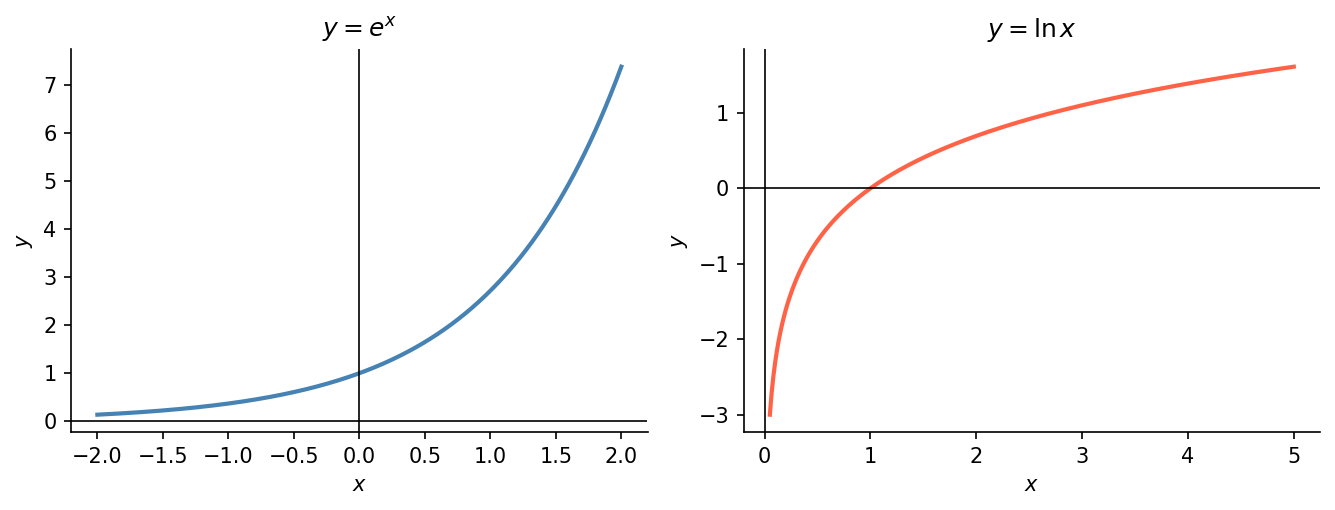

In [3]:
x = sym.Symbol('x')

# Demonstrate key identities symbolically
a, b = sym.symbols('a b', positive=True)
r = sym.Symbol('r', real=True)

print("Exponential product rule:")
print("  exp(a)*exp(b) =", sym.simplify(sym.exp(a) * sym.exp(b)), "= exp(a+b)?",
      sym.simplify(sym.exp(a) * sym.exp(b) - sym.exp(a + b)) == 0)

print()
print("Logarithm of a product:")
lhs = sym.log(a * b)
rhs = sym.log(a) + sym.log(b)
print("  ln(a*b) - (ln(a)+ln(b)) =", sym.simplify(lhs - rhs))

print()
# Plot e^x and ln(x)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

xv = np.linspace(-2, 2, 300)
axes[0].plot(xv, np.exp(xv), color='steelblue', linewidth=2)
axes[0].axhline(0, color='k', linewidth=0.8)
axes[0].axvline(0, color='k', linewidth=0.8)
axes[0].set_title(r'$y = e^x$')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$y$')

xv2 = np.linspace(0.05, 5, 300)
axes[1].plot(xv2, np.log(xv2), color='tomato', linewidth=2)
axes[1].axhline(0, color='k', linewidth=0.8)
axes[1].axvline(0, color='k', linewidth=0.8)
axes[1].set_title(r'$y = \ln x$')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$y$')

plt.tight_layout()
plt.savefig('exp_log.png', bbox_inches='tight')
plt.show()

### Trigonometric and Inverse Trigonometric Functions

The six trigonometric functions are defined via the unit circle. The two
that arise most often in differential equations are $\sin x$ and
$\cos x$, which satisfy

$$\sin^2 x + \cos^2 x = 1$$

and the derivative relations $\frac{d}{dx}\sin x = \cos x$ and
$\frac{d}{dx}\cos x = -\sin x$. These make $\sin$ and $\cos$ the natural
basis of solutions to the equation $y'' + y = 0$ and, more generally, to
any constant-coefficient linear ODE whose characteristic roots are
purely imaginary.

Key identities used frequently in this course:

| Identity              | Formula                                           |
|-----------------------|---------------------------------------------------|
| Pythagorean           | $\sin^2 x + \cos^2 x = 1$                         |
| Double angle (sine)   | $\sin 2x = 2\sin x \cos x$                        |
| Double angle (cosine) | $\cos 2x = \cos^2 x - \sin^2 x$                   |
| Half-angle (sine)     | $\sin^2 x = \dfrac{1 - \cos 2x}{2}$               |
| Half-angle (cosine)   | $\cos^2 x = \dfrac{1 + \cos 2x}{2}$               |
| Sum-to-product        | $\sin(A \pm B) = \sin A \cos B \pm \cos A \sin B$ |
| Sum-to-product        | $\cos(A \pm B) = \cos A \cos B \mp \sin A \sin B$ |

Selected trigonometric identities {.table-striped}

The **inverse trigonometric functions** $\arcsin x$, $\arccos x$, and
$\arctan x$ arise in antiderivatives of algebraic expressions. The most
common in this course is

$$\int \frac{dx}{1 + x^2} = \arctan x + C.$$

sin²(x) + cos²(x) = 1
sin(2x) - 2sin(x)cos(x) = 0

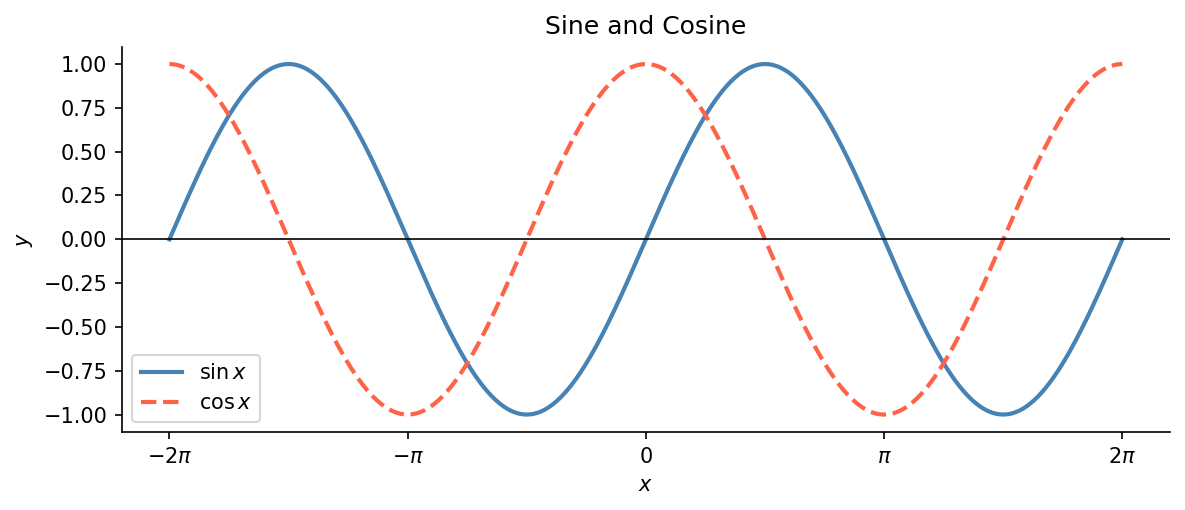

In [4]:
x = sym.Symbol('x')

# Verify the Pythagorean identity symbolically
identity = sym.trigsimp(sym.sin(x)**2 + sym.cos(x)**2)
print("sin²(x) + cos²(x) =", identity)

# Verify the double-angle formula for sin
double_angle = sym.trigsimp(sym.sin(2*x) - 2*sym.sin(x)*sym.cos(x))
print("sin(2x) - 2sin(x)cos(x) =", double_angle)

# Plot sin and cos
xv = np.linspace(-2*np.pi, 2*np.pi, 500)
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(xv, np.sin(xv), label=r'$\sin x$', color='steelblue', linewidth=2)
ax.plot(xv, np.cos(xv), label=r'$\cos x$', color='tomato', linewidth=2, linestyle='--')
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xticks([-2*np.pi, -np.pi, 0, np.pi, 2*np.pi])
ax.set_xticklabels([r'$-2\pi$', r'$-\pi$', r'$0$', r'$\pi$', r'$2\pi$'])
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Sine and Cosine')
ax.legend()
plt.tight_layout()
plt.savefig('trig.png', bbox_inches='tight')
plt.show()

### Hyperbolic Functions

The **hyperbolic functions** are defined in terms of the exponential
function:

$$\cosh x = \frac{e^x + e^{-x}}{2}, \qquad \sinh x = \frac{e^x - e^{-x}}{2}.$$

They satisfy an identity analogous to the Pythagorean theorem,

$$\cosh^2 x - \sinh^2 x = 1,$$

and their derivatives mirror (with a sign change) those of the circular
trig functions:

$$\frac{d}{dx}\sinh x = \cosh x, \qquad \frac{d}{dx}\cosh x = \sinh x.$$

Hyperbolic functions appear as solutions to the ODE $y'' - y = 0$ (note
the minus sign, versus $y'' + y = 0$ for circular functions), and arise
in problems involving catenary curves, heat conduction, and certain
boundary-value problems. The remaining hyperbolic functions are defined
analogously: $\tanh x = \sinh x / \cosh x$, etc.

cosh²(x) - sinh²(x) = 1
d/dx sinh(x) = cosh(x)
d/dx cosh(x) = sinh(x)

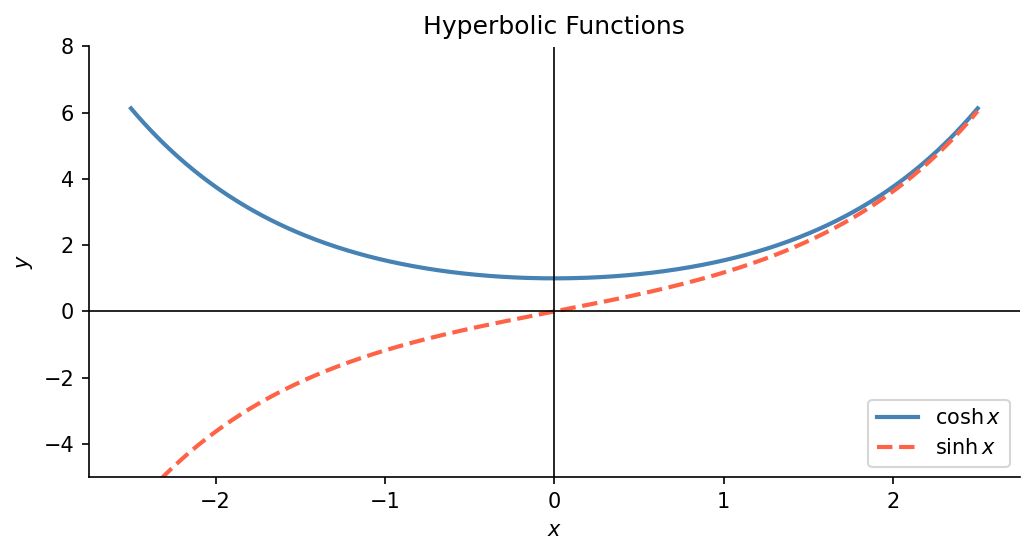

In [5]:
x = sym.Symbol('x')

# Verify the hyperbolic Pythagorean identity
hyp_id = sym.simplify(sym.cosh(x)**2 - sym.sinh(x)**2)
print("cosh²(x) - sinh²(x) =", hyp_id)

# Derivatives
print("d/dx sinh(x) =", sym.diff(sym.sinh(x), x))
print("d/dx cosh(x) =", sym.diff(sym.cosh(x), x))

# Plot sinh and cosh
xv = np.linspace(-2.5, 2.5, 400)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(xv, np.cosh(xv), label=r'$\cosh x$', color='steelblue', linewidth=2)
ax.plot(xv, np.sinh(xv), label=r'$\sinh x$', color='tomato', linewidth=2, linestyle='--')
ax.axhline(0, color='k', linewidth=0.8)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_ylim(-5, 8)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Hyperbolic Functions')
ax.legend()
plt.tight_layout()
plt.savefig('hyperbolic.png', bbox_inches='tight')
plt.show()

## Derivatives

### Derivative Rules

The fundamental **differentiation rules** used throughout this course
are collected below. Let $f$ and $g$ be differentiable functions, and
let $c$ be a constant.

| Rule | Formula |
|------------------------------------|------------------------------------|
| Constant | $\dfrac{d}{dx}[c] = 0$ |
| Constant multiple | $\dfrac{d}{dx}[c\,f] = c\,f'$ |
| Sum / Difference | $\dfrac{d}{dx}[f \pm g] = f' \pm g'$ |
| Product | $\dfrac{d}{dx}[f\,g] = f'g + fg'$ |
| Quotient | $\dfrac{d}{dx}\!\left[\dfrac{f}{g}\right] = \dfrac{f'g - fg'}{g^2}$ |
| Chain | $\dfrac{d}{dx}[f(g(x))] = f'(g(x))\,g'(x)$ |

Differentiation rules {.table-striped}

The **chain rule** is particularly important in differential equations
because solutions frequently take the form $e^{rt}$, $\sin(\omega t)$,
or other composed functions whose derivatives we must compute routinely.

In [6]:
x = sym.Symbol('x')

# Demonstrate product, quotient, and chain rules with SymPy
f = sym.exp(x) * sym.sin(x)          # product
g = sym.sin(x) / (1 + x**2)          # quotient
h = sym.exp(-x**2)                    # chain rule (composition)

print("Product rule example:")
print("  f(x)  =", f)
print("  f'(x) =", sym.diff(f, x))

print()
print("Quotient rule example:")
print("  g(x)  =", g)
print("  g'(x) =", sym.simplify(sym.diff(g, x)))

print()
print("Chain rule example:")
print("  h(x)  =", h)
print("  h'(x) =", sym.diff(h, x))

Product rule example:
  f(x)  = exp(x)*sin(x)
  f'(x) = exp(x)*sin(x) + exp(x)*cos(x)

Quotient rule example:
  g(x)  = sin(x)/(x**2 + 1)
  g'(x) = (-2*x*sin(x) + (x**2 + 1)*cos(x))/(x**2 + 1)**2

Chain rule example:
  h(x)  = exp(-x**2)
  h'(x) = -2*x*exp(-x**2)

### Basic Derivatives and Antiderivatives

The table below lists the derivatives and corresponding antiderivatives
(indefinite integrals) that appear most frequently in MATH 341. In each
antiderivative, $C$ denotes an arbitrary constant of integration.

| Function $f(x)$ | Derivative $f'(x)$ | Antiderivative $\displaystyle\int f(x)\,dx$ |
|------------------------|------------------------|------------------------|
| $x^n$ | $n x^{n-1}$ | $\dfrac{x^{n+1}}{n+1} + C \quad (n\neq -1)$ |
| $\ln\lvert x\rvert$ | $\dfrac{1}{x}$ | $x\ln\lvert x\rvert - x + C$ |
| $e^{ax}$ | $a e^{ax}$ | $\dfrac{1}{a}e^{ax} + C$ |
| $\sin(ax)$ | $a\cos(ax)$ | $-\dfrac{1}{a}\cos(ax) + C$ |
| $\cos(ax)$ | $-a\sin(ax)$ | $\dfrac{1}{a}\sin(ax) + C$ |
| $\tan x$ | $\sec^2 x$ | $-\ln\lvert\cos x\rvert + C$ |
| $\sinh(ax)$ | $a\cosh(ax)$ | $\dfrac{1}{a}\cosh(ax) + C$ |
| $\cosh(ax)$ | $a\sinh(ax)$ | $\dfrac{1}{a}\sinh(ax) + C$ |
| $\dfrac{1}{x^2 + a^2}$ | — | $\dfrac{1}{a}\arctan\!\left(\dfrac{x}{a}\right) + C$ |
| $\dfrac{1}{\sqrt{a^2 - x^2}}$ | — | $\arcsin\!\left(\dfrac{x}{a}\right) + C$ |

Basic derivatives and antiderivatives {.table-striped}

In [7]:
x, a = sym.symbols('x a', real=True, positive=True)

# Verify several entries in the table using SymPy
entries = [
    ("x^n",            x**sym.Symbol('n')),
    ("e^(ax)",         sym.exp(a*x)),
    ("sin(ax)",        sym.sin(a*x)),
    ("cos(ax)",        sym.cos(a*x)),
    ("1/(x^2+a^2)",    1 / (x**2 + a**2)),
]

print(f"{'Function':<20}  {'Derivative':<30}  {'Antiderivative (no C)'}")
print("-" * 85)
for name, expr in entries:
    deriv = sym.diff(expr, x)
    antideriv = sym.integrate(expr, x)
    print(f"{name:<20}  {str(sym.simplify(deriv)):<30}  {antideriv}")

Function              Derivative                      Antiderivative (no C)
-------------------------------------------------------------------------------------
x^n                   n*x**(n - 1)                    Piecewise((x**(n + 1)/(n + 1), Ne(n, -1)), (log(x), True))
e^(ax)                a*exp(a*x)                      exp(a*x)/a
sin(ax)               a*cos(a*x)                      -cos(a*x)/a
cos(ax)               -a*sin(a*x)                     sin(a*x)/a
1/(x^2+a^2)           -2*x/(a**2 + x**2)**2           atan(x/a)/a

## Integration Techniques

### Substitution

**$u$-substitution** reverses the chain rule. If $u = g(x)$ so that
$du = g'(x)\,dx$, then

$$\int f(g(x))\,g'(x)\,dx = \int f(u)\,du.$$

**Strategy:** Choose $u$ to be an “inner” function whose derivative also
appears (or can be manufactured) in the integrand.

> **Example**
>
> Evaluate $\displaystyle\int x e^{x^2}\,dx$.
>
> Let $u = x^2$, so $du = 2x\,dx$, i.e. $x\,dx = \tfrac{1}{2}\,du$. Then
>
> $$\int x e^{x^2}\,dx = \frac{1}{2}\int e^u\,du = \frac{1}{2}e^u + C = \frac{1}{2}e^{x^2} + C.$$

In [8]:
x = sym.Symbol('x')

# SymPy computes the substitution automatically
integrand = x * sym.exp(x**2)
result = sym.integrate(integrand, x)
print("∫ x·exp(x²) dx =", result)

# A definite integral with substitution: ∫₀¹ 2x/(1+x²) dx
integrand2 = 2*x / (1 + x**2)
result2 = sym.integrate(integrand2, (x, 0, 1))
print()
print("∫₀¹ 2x/(1+x²) dx =", result2, "=", sym.simplify(result2))
print("Note: ln(2) ≈", float(sym.log(2)))

∫ x·exp(x²) dx = exp(x**2)/2

∫₀¹ 2x/(1+x²) dx = log(2) = log(2)
Note: ln(2) ≈ 0.6931471805599453

### Integration by Parts

**Integration by parts** reverses the product rule:

$$\int u\,dv = uv - \int v\,du.$$

The classic mnemonic for choosing $u$ is **LIATE**: Logarithms, Inverse
trig, Algebraic (polynomials), Trigonometric, Exponential — pick $u$ as
the function that appears earliest in this list.

> **Example**
>
> Evaluate $\displaystyle\int t e^{-t}\,dt$.
>
> Set $u = t$ and $dv = e^{-t}\,dt$. Then $du = dt$ and $v = -e^{-t}$.
> Thus
>
> $$\int t e^{-t}\,dt = -t e^{-t} + \int e^{-t}\,dt = -t e^{-t} - e^{-t} + C = -e^{-t}(t+1) + C.$$
>
> This type of integral arises naturally when computing inverse Laplace
> transforms of functions like $\frac{1}{(s+1)^2}$.

Sometimes integration by parts must be applied **twice**, or the
original integral reappears on the right-hand side and can be solved
algebraically (the “loop” trick):

$$\int e^{ax}\cos(bx)\,dx = \frac{e^{ax}(a\cos bx + b\sin bx)}{a^2 + b^2} + C.$$

In [9]:
x, a, b = sym.symbols('x a b', real=True)
t = sym.Symbol('t')

# Example 1: ∫ t·e^{-t} dt
result1 = sym.integrate(t * sym.exp(-t), t)
print("∫ t·exp(-t) dt =", result1)

# Example 2: double integration by parts
result2 = sym.integrate(sym.exp(a*x) * sym.cos(b*x), x)
print()
print("∫ exp(ax)·cos(bx) dx =", sym.simplify(result2))

# Example 3: ∫ x²·sin(x) dx  (needs two rounds of by-parts)
result3 = sym.integrate(x**2 * sym.sin(x), x)
print()
print("∫ x²·sin(x) dx =", result3)

∫ t·exp(-t) dt = (-t - 1)*exp(-t)

∫ exp(ax)·cos(bx) dx = Piecewise((x, Eq(a, 0) & Eq(b, 0)), ((b*x*exp(I*b*x) + sin(b*x))*exp(-I*b*x)/(2*b), Eq(a, -I*b)), ((b*x*exp(-I*b*x) + sin(b*x))*exp(I*b*x)/(2*b), Eq(a, I*b)), ((a*cos(b*x) + b*sin(b*x))*exp(a*x)/(a**2 + b**2), True))

∫ x²·sin(x) dx = -x**2*cos(x) + 2*x*sin(x) + 2*cos(x)

### Partial Fractions

**Partial fraction decomposition** expresses a proper rational function
as a sum of simpler fractions that can be integrated term by term. It is
also the primary tool for computing inverse Laplace transforms.

Given $r(x) = p(x)/q(x)$ with $\deg p < \deg q$, factor $q(x)$ over the
reals and write:

- For each **linear factor** $(x - a)^k$:
  $$\frac{A_1}{x-a} + \frac{A_2}{(x-a)^2} + \cdots + \frac{A_k}{(x-a)^k}$$

- For each **irreducible quadratic factor** $(x^2 + bx + c)^k$:
  $$\frac{B_1 x + C_1}{x^2+bx+c} + \frac{B_2 x + C_2}{(x^2+bx+c)^2} + \cdots$$

> **Example**
>
> Decompose $\displaystyle\frac{3x + 5}{(x-1)(x+3)}$ into partial
> fractions.
>
> Write $\dfrac{3x+5}{(x-1)(x+3)} = \dfrac{A}{x-1} + \dfrac{B}{x+3}$.
>
> Multiplying through: $3x + 5 = A(x+3) + B(x-1)$.
>
> Setting $x = 1$: $8 = 4A \Rightarrow A = 2$. Setting $x = -3$:
> $-4 = -4B \Rightarrow B = 1$.
>
> $$\frac{3x+5}{(x-1)(x+3)} = \frac{2}{x-1} + \frac{1}{x+3}.$$

In [10]:
x = sym.Symbol('x')

# Example 1: linear factors
r1 = (3*x + 5) / ((x - 1)*(x + 3))
print("Partial fraction decomposition:")
print("  (3x+5)/[(x-1)(x+3)] =", sym.apart(r1, x))

# Example 2: repeated linear factor
r2 = (2*x + 3) / ((x + 1)**2 * (x - 2))
print()
print("  (2x+3)/[(x+1)²(x-2)] =", sym.apart(r2, x))

# Example 3: irreducible quadratic factor
r3 = (x**2 + x + 1) / ((x - 1)*(x**2 + 1))
print()
print("  (x²+x+1)/[(x-1)(x²+1)] =", sym.apart(r3, x))

# Integrate the first example to confirm
print()
print("∫ [(3x+5)/((x-1)(x+3))] dx =", sym.integrate(r1, x))

Partial fraction decomposition:
  (3x+5)/[(x-1)(x+3)] = 1/(x + 3) + 2/(x - 1)

  (2x+3)/[(x+1)²(x-2)] = -7/(9*(x + 1)) - 1/(3*(x + 1)**2) + 7/(9*(x - 2))

  (x²+x+1)/[(x-1)(x²+1)] = -(x - 1)/(2*(x**2 + 1)) + 3/(2*(x - 1))

∫ [(3x+5)/((x-1)(x+3))] dx = 2*log(x - 1) + log(x + 3)

## Taylor Series

The **Taylor series** of a smooth function $f$ centered at $x = a$ is

$$f(x) = \sum_{n=0}^{\infty} \frac{f^{(n)}(a)}{n!}(x-a)^n
      = f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a)^2 + \cdots$$

When $a = 0$ this is called a **Maclaurin series**. The series converges
to $f(x)$ on an interval of radius $R$ (the **radius of convergence**)
centered at $a$.

The four Maclaurin series used most often in differential equations are:

$$e^x = \sum_{n=0}^{\infty} \frac{x^n}{n!} = 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \cdots, \quad R = \infty$$

$$\sin x = \sum_{n=0}^{\infty} \frac{(-1)^n x^{2n+1}}{(2n+1)!} = x - \frac{x^3}{3!} + \frac{x^5}{5!} - \cdots, \quad R = \infty$$

$$\cos x = \sum_{n=0}^{\infty} \frac{(-1)^n x^{2n}}{(2n)!} = 1 - \frac{x^2}{2!} + \frac{x^4}{4!} - \cdots, \quad R = \infty$$

$$\frac{1}{1-x} = \sum_{n=0}^{\infty} x^n = 1 + x + x^2 + x^3 + \cdots, \quad \lvert x\rvert < 1$$

**Euler’s formula** ties together the exponential and trigonometric
series:

$$e^{i\theta} = \cos\theta + i\sin\theta,$$

and is used extensively when solving linear ODEs with complex
characteristic roots.

  exp(x) ≈ x**8/40320 + x**7/5040 + x**6/720 + x**5/120 + x**4/24 + x**3/6 + x**2/2 + x + 1
  sin(x) ≈ -x**7/5040 + x**5/120 - x**3/6 + x
  cos(x) ≈ x**8/40320 - x**6/720 + x**4/24 - x**2/2 + 1
  1/(1-x) ≈ x**8 + x**7 + x**6 + x**5 + x**4 + x**3 + x**2 + x + 1


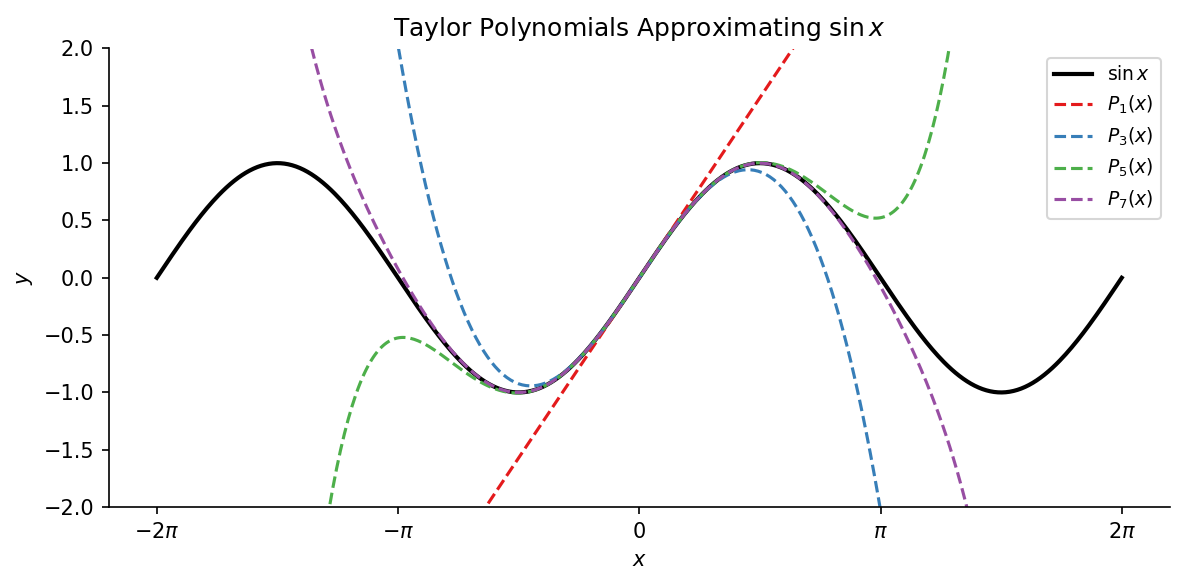

In [11]:
x = sym.Symbol('x')

# Compute Maclaurin series up to order 8
funcs = {
    'exp(x)':   sym.exp(x),
    'sin(x)':   sym.sin(x),
    'cos(x)':   sym.cos(x),
    '1/(1-x)':  1/(1 - x),
}

for name, f in funcs.items():
    series = sym.series(f, x, 0, n=9).removeO()
    print(f"  {name} ≈ {series}")
print()

# Illustrate how partial sums approximate sin(x)
xv = np.linspace(-2*np.pi, 2*np.pi, 500)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(xv, np.sin(xv), 'k', linewidth=2, label=r'$\sin x$')

import math
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
for k, (n, color) in enumerate(zip([1, 2, 3, 4], colors)):
    # Partial sum: x - x³/3! + x⁵/5! - ... up to term 2n-1
    s = sum((-1)**m * xv**(2*m+1) / float(math.factorial(2*m+1)) for m in range(n))
    ax.plot(xv, s, color=color, linewidth=1.5, linestyle='--',
            label=rf'$P_{{{2*n-1}}}(x)$')

ax.set_ylim(-2, 2)
ax.set_xticks([-2*np.pi, -np.pi, 0, np.pi, 2*np.pi])
ax.set_xticklabels([r'$-2\pi$', r'$-\pi$', '$0$', r'$\pi$', r'$2\pi$'])
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Taylor Polynomials Approximating $\\sin x$')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('taylor_sin.png', bbox_inches='tight')
plt.show()

## Parametric Curves

A **parametric curve** in the plane is described by a pair of functions

$$x = x(t), \qquad y = y(t), \qquad t \in [a, b].$$

The variable $t$ is the **parameter**, and is often interpreted as time.
The curve traces the set of points $\bigl(x(t), y(t)\bigr)$ as $t$
varies.

**Slope of the tangent line.** Applying the chain rule,

$$\frac{dy}{dx} = \frac{dy/dt}{dx/dt}, \qquad \frac{dx}{dt} \neq 0.$$

**Arc length.** The length of the curve from $t = a$ to $t = b$ is

$$L = \int_a^b \sqrt{\left(\frac{dx}{dt}\right)^2 + \left(\frac{dy}{dt}\right)^2}\,dt.$$

Parametric curves are most relevant in MATH 341 when we study **systems
of differential equations**, where the solution $(x(t), y(t))$ is a
curve in the **phase plane**. Plotting these trajectories is a central
tool for understanding the long-time behavior of a system.

Parametric curve: x(t) = cos(2t), y(t) = sin(3t)
dx/dt = -2*sin(2*t)
dy/dt = 3*cos(3*t)
dy/dx = -3*cos(3*t)/(2*sin(2*t))

Arc length over [0, 2π] ≈ 15.20921

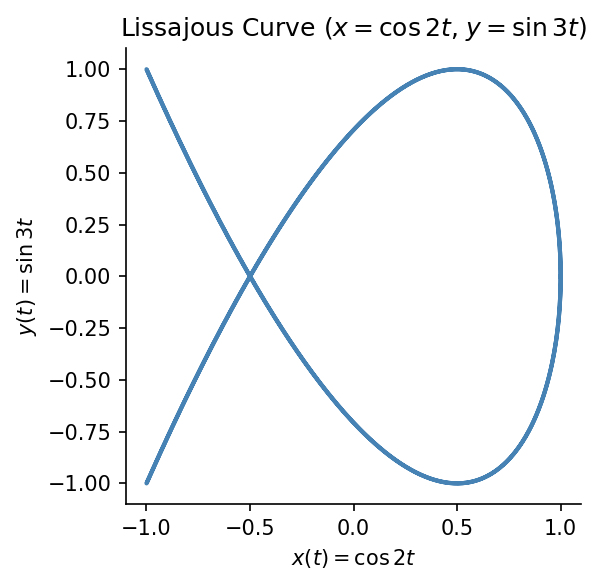

In [12]:
t = sym.Symbol('t')

# Lissajous-type parametric curve
x_t = sym.cos(2*t)
y_t = sym.sin(3*t)

# Compute dy/dx
dydx = sym.simplify(sym.diff(y_t, t) / sym.diff(x_t, t))
print("Parametric curve: x(t) = cos(2t), y(t) = sin(3t)")
print("dx/dt =", sym.diff(x_t, t))
print("dy/dt =", sym.diff(y_t, t))
print("dy/dx =", dydx)

# Arc length over [0, 2π]  -- numerical since the integral is elliptic
L_num, _ = sp.integrate.quad(
    lambda tv: np.sqrt((-2*np.sin(2*tv))**2 + (3*np.cos(3*tv))**2),
    0, 2*np.pi
)
print(f"\nArc length over [0, 2π] ≈ {L_num:.5f}")

# Plot the Lissajous curve
tv = np.linspace(0, 2*np.pi, 1000)
xv = np.cos(2*tv)
yv = np.sin(3*tv)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(xv, yv, color='steelblue', linewidth=2)
ax.set_aspect('equal')
ax.set_xlabel('$x(t) = \\cos 2t$')
ax.set_ylabel('$y(t) = \\sin 3t$')
ax.set_title('Lissajous Curve ($x = \\cos 2t$, $y = \\sin 3t$)')
plt.tight_layout()
plt.savefig('parametric.png', bbox_inches='tight')
plt.show()

## Partial Derivatives

For a function $F(x, y)$ of two variables, the **partial derivative**
with respect to $x$ is defined by treating $y$ as a constant:

$$F_x = \frac{\partial F}{\partial x} = \lim_{h \to 0} \frac{F(x+h, y) - F(x, y)}{h}.$$

Similarly, $F_y = \partial F / \partial y$ treats $x$ as a constant.
Higher-order partial derivatives are computed iteratively. For functions
with continuous second-order partials, **Clairaut’s theorem** guarantees
symmetry:

$$F_{xy} = \frac{\partial^2 F}{\partial y \partial x} = \frac{\partial^2 F}{\partial x \partial y} = F_{yx}.$$

**Exactness.** Partial derivatives play a central role in **exact
differential equations**. An expression $M(x,y)\,dx + N(x,y)\,dy$ is an
**exact differential** if and only if

$$\frac{\partial M}{\partial y} = \frac{\partial N}{\partial x}.$$

In that case there exists a potential function $F(x,y)$ such that
$F_x = M$ and $F_y = N$, and the general solution is $F(x,y) = C$.

**The total derivative.** If $y = y(x)$ is implicitly a function of $x$
through a relation $F(x,y) = C$, then differentiating with respect to
$x$ gives

$$\frac{dF}{dx} = F_x + F_y \frac{dy}{dx} = 0 \implies \frac{dy}{dx} = -\frac{F_x}{F_y}.$$

In [13]:
x, y = sym.symbols('x y')

# Example function
F = x**3 * y**2 - sym.exp(x*y) + sym.sin(x + y**2)

Fx = sym.diff(F, x)
Fy = sym.diff(F, y)
Fxy = sym.diff(F, x, y)
Fyx = sym.diff(F, y, x)

print("F(x,y) =", F)
print()
print("∂F/∂x =", Fx)
print()
print("∂F/∂y =", Fy)
print()
print("∂²F/∂y∂x =", sym.simplify(Fxy))
print("∂²F/∂x∂y =", sym.simplify(Fyx))
print("Equal (Clairaut's thm):", sym.simplify(Fxy - Fyx) == 0)

# Exactness check for an exact equation M dx + N dy
print()
print("--- Exactness example ---")
M = 2*x*y + 3*x**2
N = x**2 + 4*y**3
print("M =", M, "  N =", N)
print("∂M/∂y =", sym.diff(M, y))
print("∂N/∂x =", sym.diff(N, x))
print("Exact?", sym.diff(M, y) == sym.diff(N, x))

# Recover the potential function F
F_pot = sym.integrate(M, x) + sym.Function('g')(y)
print()
print("Potential F (integrating M with respect to x):")
print(" F =", sym.integrate(M, x), "+ g(y)")
g_deriv = sym.diff(sym.integrate(M, x), y) - N
print(" g'(y) = N - ∂/∂y[∫M dx] =", sym.simplify(g_deriv + N - N), "... solving:", sym.simplify(-g_deriv))
g_y = sym.integrate(-g_deriv, y)
print(" g(y) =", g_y)
F_final = sym.integrate(M, x) + g_y
print(" F(x,y) =", sym.expand(F_final))

F(x,y) = x**3*y**2 - exp(x*y) + sin(x + y**2)

∂F/∂x = 3*x**2*y**2 - y*exp(x*y) + cos(x + y**2)

∂F/∂y = 2*x**3*y - x*exp(x*y) + 2*y*cos(x + y**2)

∂²F/∂y∂x = 6*x**2*y - x*y*exp(x*y) - 2*y*sin(x + y**2) - exp(x*y)
∂²F/∂x∂y = 6*x**2*y - x*y*exp(x*y) - 2*y*sin(x + y**2) - exp(x*y)
Equal (Clairaut's thm): True

--- Exactness example ---
M = 3*x**2 + 2*x*y   N = x**2 + 4*y**3
∂M/∂y = 2*x
∂N/∂x = 2*x
Exact? True

Potential F (integrating M with respect to x):
 F = x**3 + x**2*y + g(y)
 g'(y) = N - ∂/∂y[∫M dx] = -4*y**3 ... solving: 4*y**3
 g(y) = y**4
 F(x,y) = x**3 + x**2*y + y**4

## Optimization

Optimization is the problem of finding the input values that minimize or
maximize a given function. In a first course on ODEs the topic arises
naturally in several places: equilibrium analysis (where we ask whether
a steady state is stable), parameter estimation (fitting a model to data
by minimizing a residual), and certain boundary-value problems derived
from variational principles. This section reviews the essential ideas
for both single- and multi-variable settings and shows how to carry out
computations with SymPy and SciPy.

### Single-Variable Optimization

Given a differentiable function $f : \mathbb{R} \to \mathbb{R}$, a point
$x^*$ is a **critical point** if $f'(x^*) = 0$ or $f'$ does not exist
there. The **second derivative test** then classifies the critical
point:

$$f''(x^*) > 0 \implies \text{local minimum}, \qquad f''(x^*) < 0 \implies \text{local maximum}, \qquad f''(x^*) = 0 \implies \text{inconclusive}.$$

A **global** (absolute) extremum on a closed interval $[a, b]$ is found
by evaluating $f$ at every critical point in $(a,b)$ and at the
endpoints $a$, $b$, then comparing.

> **Example**
>
> Find and classify the critical points of $f(x) = x^3 - 3x^2 - 9x + 5$.
>
> Setting $f'(x) = 3x^2 - 6x - 9 = 3(x-3)(x+1) = 0$ gives $x^* = -1$ and
> $x^* = 3$.
>
> $f''(x) = 6x - 6$, so $f''(-1) = -12 < 0$ (local max) and
> $f''(3) = 12 > 0$ (local min).

f(x)   = x**3 - 3*x**2 - 9*x + 5
f'(x)  = 3*x**2 - 6*x - 9
f''(x) = 6*(x - 1)

  x* =  -1:  f(x*) =   10,  f''(x*) =  -12  →  local max
  x* =   3:  f(x*) =  -22,  f''(x*) =   12  →  local min

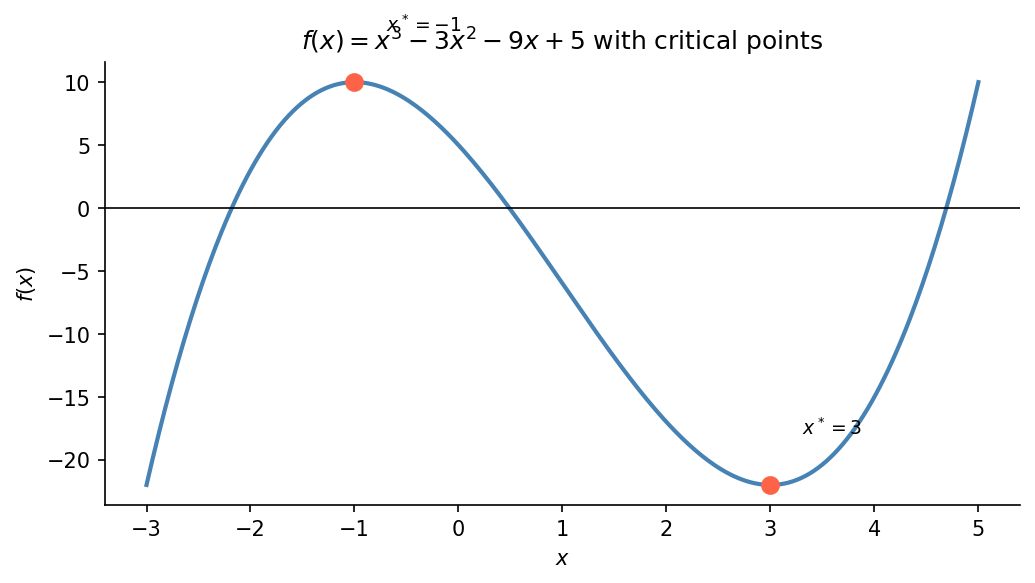

In [14]:
x = sym.Symbol('x')

f = x**3 - 3*x**2 - 9*x + 5

# Symbolic critical points and classification
fp  = sym.diff(f, x)
fpp = sym.diff(f, x, 2)
crits = sym.solve(fp, x)

print("f(x)   =", f)
print("f'(x)  =", fp)
print("f''(x) =", fpp)
print()
for c in crits:
    second = fpp.subs(x, c)
    kind = "local min" if second > 0 else "local max" if second < 0 else "inconclusive"
    print(f"  x* = {int(c):>3}:  f(x*) = {int(f.subs(x,c)):>4},  f''(x*) = {int(second):>4}  →  {kind}")

# Plot
xv = np.linspace(-3, 5, 400)
fv = xv**3 - 3*xv**2 - 9*xv + 5

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(xv, fv, color='steelblue', linewidth=2)
for c in crits:
    cv = float(c)
    fval = float(f.subs(x, c))
    ax.plot(cv, fval, 'o', color='tomato', markersize=8, zorder=5)
    ax.annotate(f'$x^*={c}$', xy=(cv, fval),
                xytext=(cv + 0.3, fval + 4), fontsize=9)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title(r'$f(x) = x^3 - 3x^2 - 9x + 5$ with critical points')
plt.tight_layout()
plt.savefig('opt_1d.png', bbox_inches='tight')
plt.show()

For optimization problems where a closed-form solution is unavailable,
`scipy.optimize.minimize_scalar` finds a local minimum numerically over
an interval.

In [15]:
from scipy.optimize import minimize_scalar

# Minimize f(x) = x^3 - 3x^2 - 9x + 5 on [-2, 5]
def f_num(xv):
    return xv**3 - 3*xv**2 - 9*xv + 5

result = minimize_scalar(f_num, bounds=(-2, 5), method='bounded')
print("scipy.optimize.minimize_scalar result:")
print(f"  x* ≈ {result.x:.6f}")
print(f"  f(x*) ≈ {result.fun:.6f}")
print(f"  Success: {result.success}")

scipy.optimize.minimize_scalar result:
  x* ≈ 3.000001
  f(x*) ≈ -22.000000
  Success: True

### Multi-Variable Optimization

For a function $f : \mathbb{R}^n \to \mathbb{R}$, a necessary condition
for an interior local extremum is that the **gradient** vanishes:

$$\nabla f(\mathbf{x}^*) = \mathbf{0}, \qquad
\nabla f = \left(\frac{\partial f}{\partial x_1},\, \frac{\partial f}{\partial x_2},\, \ldots,\, \frac{\partial f}{\partial x_n}\right)^{\!\top}.$$

The nature of a critical point in $\mathbb{R}^2$ is determined by the
**Hessian matrix**

$$H(f) = \begin{pmatrix} f_{xx} & f_{xy} \\ f_{xy} & f_{yy} \end{pmatrix},$$

evaluated at the critical point. The **second-order test** uses the
determinant $D = f_{xx}f_{yy} - f_{xy}^2$:

| Condition                | Conclusion    |
|--------------------------|---------------|
| $D > 0$ and $f_{xx} > 0$ | local minimum |
| $D > 0$ and $f_{xx} < 0$ | local maximum |
| $D < 0$                  | saddle point  |
| $D = 0$                  | inconclusive  |

Second-order test for functions of two variables {.table-striped}

> **Example**
>
> Classify the critical points of $f(x,y) = x^3 + y^3 - 3xy$.
>
> Setting $f_x = 3x^2 - 3y = 0$ and $f_y = 3y^2 - 3x = 0$ gives
> $y = x^2$ and $x = y^2$, yielding critical points $(0,0)$ and $(1,1)$.
>
> At $(1,1)$: $f_{xx} = 6$, $f_{yy} = 6$, $f_{xy} = -3$, so
> $D = 36 - 9 = 27 > 0$ and $f_{xx} > 0$ — a local minimum.
>
> At $(0,0)$: $f_{xx} = 0$, $f_{yy} = 0$, $f_{xy} = -3$, so $D = -9 < 0$
> — a saddle point.

f(x,y) = x**3 - 3*x*y + y**3
∇f = [3*x**2 - 3*y, -3*x + 3*y**2]

All critical points: [(0, 0), (1, 1), ((-1/2 - sqrt(3)*I/2)**2, -1/2 - sqrt(3)*I/2), ((-1/2 + sqrt(3)*I/2)**2, -1/2 + sqrt(3)*I/2)]
Real critical points: [(0, 0), (1, 1)]

  (0, 0):  f = 0,  D = -9.0,  f_xx = 0.0  ->  saddle point
  (1, 1):  f = -1,  D = 27.0,  f_xx = 6.0  ->  local min

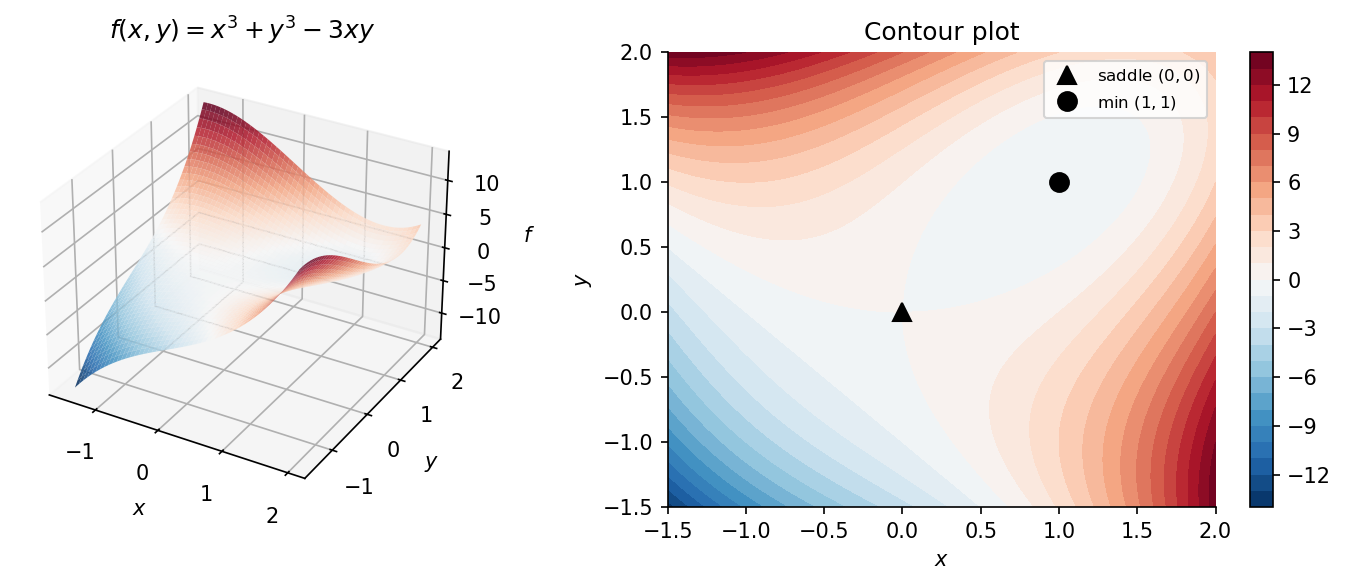

In [16]:
x, y = sym.symbols('x y')

f2 = x**3 + y**3 - 3*x*y

# Gradient and Hessian
grad = [sym.diff(f2, v) for v in (x, y)]
H = sym.hessian(f2, (x, y))

print("f(x,y) =", f2)
print("∇f =", grad)
print()

# Critical points — keep only real solutions
crits2_all = sym.solve(grad, [x, y])
crits2 = [pt for pt in crits2_all if all(v.is_real for v in pt)]
print("All critical points:", crits2_all)
print("Real critical points:", crits2)
print()

for pt in crits2:
    H_val = H.subs([(x, pt[0]), (y, pt[1])])
    D = float(H_val.det())       # cast to Python float for boolean comparisons
    fxx = float(H_val[0, 0])
    fval = f2.subs([(x, pt[0]), (y, pt[1])])
    if D > 0 and fxx > 0:
        kind = "local min"
    elif D > 0 and fxx < 0:
        kind = "local max"
    elif D < 0:
        kind = "saddle point"
    else:
        kind = "inconclusive"
    print(f"  ({pt[0]}, {pt[1]}):  f = {fval},  D = {D},  f_xx = {fxx}  ->  {kind}")

# Surface and contour plot
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

xv = np.linspace(-1.5, 2, 200)
yv = np.linspace(-1.5, 2, 200)
Xg, Yg = np.meshgrid(xv, yv)
Zg = Xg**3 + Yg**3 - 3*Xg*Yg

fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(Xg, Yg, Zg, cmap='RdBu_r', alpha=0.85, linewidth=0)
ax1.set_xlabel('$x$'); ax1.set_ylabel('$y$'); ax1.set_zlabel('$f$')
ax1.set_title(r'$f(x,y)=x^3+y^3-3xy$')

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contourf(Xg, Yg, Zg, levels=30, cmap='RdBu_r')
plt.colorbar(cs, ax=ax2)
ax2.plot(0, 0, 'k^', markersize=9, label='saddle $(0,0)$')
ax2.plot(1, 1, 'ko', markersize=9, label='min $(1,1)$')
ax2.set_xlabel('$x$'); ax2.set_ylabel('$y$')
ax2.set_title('Contour plot')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('opt_2d.png', bbox_inches='tight')
plt.show()

For numerical multi-variable optimization, `scipy.optimize.minimize`
provides a range of gradient-based methods. The default **BFGS** method
is a quasi-Newton scheme that builds up an approximation to the Hessian
iteratively and is well-suited to smooth unconstrained problems.

In [17]:
from scipy.optimize import minimize

def f2_num(v):
    return v[0]**3 + v[1]**3 - 3*v[0]*v[1]

# Start near the known local min at (1, 1)
x0 = np.array([0.5, 0.5])
res = minimize(f2_num, x0, method='BFGS')
print("scipy.optimize.minimize (BFGS) near (0.5, 0.5):")
print(f"  x* ≈ {res.x}")
print(f"  f(x*) ≈ {res.fun:.6f}")
print(f"  Success: {res.success}")
print(f"  Message: {res.message}")

scipy.optimize.minimize (BFGS) near (0.5, 0.5):
  x* ≈ [0.99999997 0.99999997]
  f(x*) ≈ -1.000000
  Success: True
  Message: Optimization terminated successfully.

> **Gradient and Hessian in SciPy**
>
> Many SciPy minimizers accept analytic `jac` (Jacobian/gradient) and
> `hess` (Hessian) arguments, which can dramatically improve both speed
> and accuracy. SymPy’s `lambdify` is a convenient way to convert a
> symbolic expression to a fast numerical function suitable for these
> arguments.

## Root Finding

**Root finding** means solving the equation $f(x) = 0$ (or a system
$\mathbf{F}(\mathbf{x}) = \mathbf{0}$) when no closed-form solution
exists. In the ODE context this arises when locating equilibrium points
of autonomous systems, finding eigenvalues numerically, or solving
implicit algebraic equations that appear as boundary conditions.

### Newton’s Method (Single Variable)

Given a smooth function $f$ and a starting guess $x_0$, **Newton’s
method** generates the sequence

$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}, \qquad n = 0, 1, 2, \ldots$$

Geometrically, each step replaces the curve $y = f(x)$ by its tangent
line at $(x_n, f(x_n))$ and takes the tangent’s zero as the next
iterate. When $x_0$ is close to a simple root $x^*$ and
$f'(x^*) \neq 0$, the method converges **quadratically**: the number of
correct decimal places roughly doubles each iteration.

> **Example**
>
> Find the positive root of $f(x) = x^3 - 2$ (i.e. $\sqrt[3]{2}$)
> starting from $x_0 = 1$.
>
> $f'(x) = 3x^2$, so the iteration is
> $x_{n+1} = x_n - (x_n^3 - 2)/(3x_n^2)$.

In [18]:
# Manual Newton's method implementation
def newton(f_func, df_func, x0, tol=1e-10, max_iter=50):
    """Return (root, iterations, history)."""
    x = x0
    history = [x]
    for i in range(max_iter):
        fx  = f_func(x)
        dfx = df_func(x)
        if abs(dfx) < 1e-15:
            raise ValueError("Derivative too small; Newton's method failed.")
        x_new = x - fx / dfx
        history.append(x_new)
        if abs(x_new - x) < tol:
            return x_new, i + 1, history
        x = x_new
    raise ValueError(f"Did not converge in {max_iter} iterations.")

f_cube  = lambda xv: xv**3 - 2
df_cube = lambda xv: 3 * xv**2

root, iters, hist = newton(f_cube, df_cube, x0=1.0)
print(f"Root ≈ {root:.15f}")
print(f"2^(1/3) = {2**(1/3):.15f}")
print(f"Converged in {iters} iterations")
print()
print(f"{'Iter':>5}  {'x_n':>20}  {'|f(x_n)|':>15}  {'error':>15}")
print("-" * 60)
true_root = 2**(1/3)
for k, xk in enumerate(hist):
    print(f"{k:>5}  {xk:>20.12f}  {abs(f_cube(xk)):>15.3e}  {abs(xk - true_root):>15.3e}")

Root ≈ 1.259921049894873
2^(1/3) = 1.259921049894873
Converged in 6 iterations

 Iter                   x_n         |f(x_n)|            error
------------------------------------------------------------
    0        1.000000000000        1.000e+00        2.599e-01
    1        1.333333333333        3.704e-01        7.341e-02
    2        1.263888888889        1.896e-02        3.968e-03
    3        1.259933493450        5.926e-05        1.244e-05
    4        1.259921050018        5.853e-10        1.229e-10
    5        1.259921049895        0.000e+00        0.000e+00
    6        1.259921049895        0.000e+00        0.000e+00

The quadratic convergence is visible in the `error` column: the number
of significant digits approximately doubles each step. SciPy’s `newton`
function in `scipy.optimize` provides a robust, production-quality
implementation that also handles the **secant method** (when no
derivative is supplied) and **Halley’s method** (when the second
derivative is supplied).

scipy newton result: 1.2599210498948732
scipy secant result: 1.2599210498947795

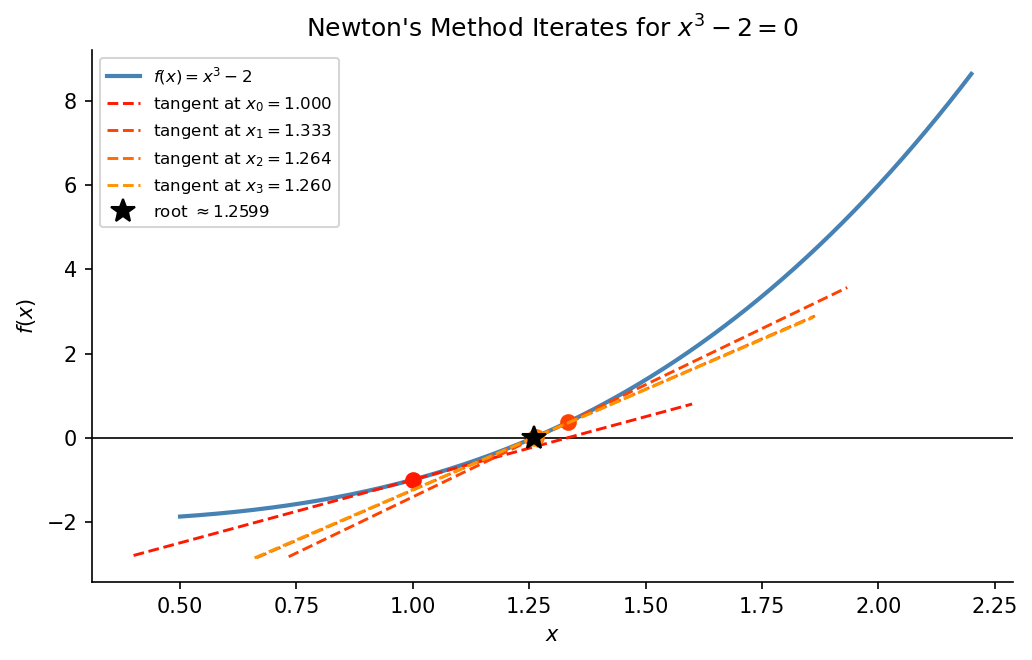

In [19]:
from scipy.optimize import newton as sp_newton

# Using scipy's newton (with analytic derivative → true Newton's method)
root_scipy = sp_newton(f_cube, x0=1.0, fprime=df_cube, full_output=True)
print("scipy newton result:", root_scipy[0])

# Without fprime → secant method
root_secant = sp_newton(f_cube, x0=1.0, full_output=True)
print("scipy secant result:", root_secant[0])

# Visualize the first few Newton iterates
xv = np.linspace(0.5, 2.2, 400)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(xv, f_cube(xv), color='steelblue', linewidth=2, label=r'$f(x)=x^3-2$')
ax.axhline(0, color='k', linewidth=0.8)

colors_n = plt.cm.autumn(np.linspace(0.1, 0.9, len(hist) - 1))
for k in range(min(4, len(hist) - 1)):
    xk = hist[k]
    fxk = f_cube(xk)
    dfxk = df_cube(xk)
    x_tang = np.linspace(xk - 0.6, xk + 0.6, 50)
    ax.plot(x_tang, fxk + dfxk * (x_tang - xk),
            color=colors_n[k], linewidth=1.4, linestyle='--',
            label=f'tangent at $x_{k}={xk:.3f}$')
    ax.plot(xk, fxk, 'o', color=colors_n[k], markersize=7)

ax.plot(root, 0, 'k*', markersize=12, zorder=6, label=f'root $\\approx {root:.4f}$')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title("Newton's Method Iterates for $x^3 - 2 = 0$")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('newton_1d.png', bbox_inches='tight')
plt.show()

#### Convergence and Limitations

Newton’s method can fail when:

- The starting guess is far from a root, causing the iterates to diverge
  or cycle.
- $f'(x_n) \approx 0$ near an iterate (near a local extremum), making
  the step size enormous.
- The root has **multiplicity** greater than one (convergence degrades
  from quadratic to linear).

The **secant method** avoids computing $f'$ by approximating it with a
finite difference:

$$x_{n+1} = x_n - f(x_n)\,\frac{x_n - x_{n-1}}{f(x_n) - f(x_{n-1})}.$$

It converges super-linearly (order $\approx 1.618$, the golden ratio),
slightly slower than Newton but requiring only function evaluations. For
bracketing problems — where a sign change is known — **Brent’s method**
(`scipy.optimize.brentq`) combines bisection, secant, and inverse
quadratic interpolation to guarantee convergence and is often the safest
general-purpose choice.

In [20]:
from scipy.optimize import brentq

# brentq requires a bracket [a, b] with f(a) and f(b) of opposite sign
root_brent = brentq(f_cube, 1.0, 2.0, full_output=True)
print(f"brentq result: root ≈ {root_brent[0]:.15f}")
print(f"Function evaluations: {root_brent[1].function_calls}")

brentq result: root ≈ 1.259921049894854
Function evaluations: 9

### Newton’s Method for Systems (Multi-Variable)

For a system $\mathbf{F}(\mathbf{x}) = \mathbf{0}$ with
$\mathbf{F} : \mathbb{R}^n \to \mathbb{R}^n$, Newton’s method
generalises to

$$\mathbf{x}_{k+1} = \mathbf{x}_k - J_F(\mathbf{x}_k)^{-1}\,\mathbf{F}(\mathbf{x}_k),$$

where $J_F$ is the **Jacobian matrix** with $(i,j)$ entry
$\partial F_i / \partial x_j$. In practice we never invert $J_F$
explicitly; instead we solve the linear system

$$J_F(\mathbf{x}_k)\,\boldsymbol{\delta} = -\mathbf{F}(\mathbf{x}_k), \qquad \mathbf{x}_{k+1} = \mathbf{x}_k + \boldsymbol{\delta},$$

at each step. This requires one LU factorisation per iteration (cost
$O(n^3)$), and the method again converges quadratically when started
sufficiently close to a simple root.

> **Example**
>
> Find the intersection of the circle $x^2 + y^2 = 4$ and the hyperbola
> $xy = 1$ in the first quadrant.
>
> Define $F_1(x,y) = x^2 + y^2 - 4$ and $F_2(x,y) = xy - 1$. The
> Jacobian is
>
> $$J_F = \begin{pmatrix} 2x & 2y \\ y & x \end{pmatrix}.$$

Root ≈ (1.9318516526, 0.5176380902)
Residual ||F(x*)|| = 4.441e-16
Converged in 5 iterations

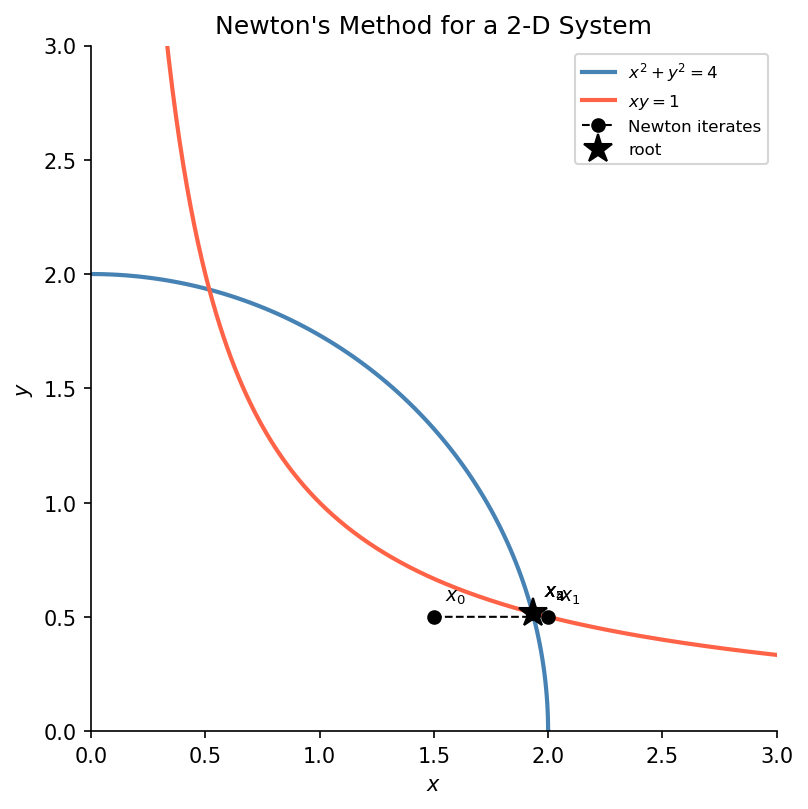

In [21]:
# Multi-variable Newton's method (manual)
def newton_system(F_func, J_func, x0, tol=1e-10, max_iter=50):
    """Return (root, iterations, history)."""
    xk = np.array(x0, dtype=float)
    history = [xk.copy()]
    for i in range(max_iter):
        Fk = F_func(xk)
        Jk = J_func(xk)
        delta = np.linalg.solve(Jk, -Fk)
        xk = xk + delta
        history.append(xk.copy())
        if np.linalg.norm(delta) < tol:
            return xk, i + 1, history
    raise ValueError("Did not converge.")

def F_sys(v):
    xv, yv = v
    return np.array([xv**2 + yv**2 - 4, xv*yv - 1])

def J_sys(v):
    xv, yv = v
    return np.array([[2*xv, 2*yv],
                     [  yv,   xv]])

root_sys, iters_sys, hist_sys = newton_system(F_sys, J_sys, x0=[1.5, 0.5])
print(f"Root ≈ ({root_sys[0]:.10f}, {root_sys[1]:.10f})")
print(f"Residual ||F(x*)|| = {np.linalg.norm(F_sys(root_sys)):.3e}")
print(f"Converged in {iters_sys} iterations")

# Plot the curves and iterates
theta = np.linspace(0, 2*np.pi, 400)
xv_circ = 2 * np.cos(theta)
yv_circ = 2 * np.sin(theta)
xv_hyp  = np.linspace(0.3, 3.5, 400)
yv_hyp  = 1 / xv_hyp

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(xv_circ, yv_circ, color='steelblue', linewidth=2, label=r'$x^2+y^2=4$')
ax.plot(xv_hyp, yv_hyp, color='tomato', linewidth=2, label=r'$xy=1$')

iterates = np.array(hist_sys)
ax.plot(iterates[:, 0], iterates[:, 1], 'k--o', markersize=6,
        linewidth=1, label='Newton iterates')
for k, pt in enumerate(iterates):
    ax.annotate(f'$x_{k}$', xy=pt, xytext=pt + np.array([0.05, 0.07]), fontsize=9)

ax.plot(*root_sys, 'k*', markersize=14, zorder=6, label='root')
ax.set_xlim(0, 3); ax.set_ylim(0, 3)
ax.set_aspect('equal')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title("Newton's Method for a 2-D System")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('newton_sys.png', bbox_inches='tight')
plt.show()

For production use, `scipy.optimize.fsolve` (a wrapper around MINPACK’s
hybrd) and `scipy.optimize.root` implement Newton-like and Krylov-based
methods for nonlinear systems and handle many edge cases automatically.

In [22]:
from scipy.optimize import fsolve, root

# fsolve with analytic Jacobian
sol_fsolve = fsolve(F_sys, x0=[1.5, 0.5], fprime=J_sys, full_output=True)
print("fsolve result:")
print(f"  root ≈ {sol_fsolve[0]}")
print(f"  residual = {np.linalg.norm(F_sys(sol_fsolve[0])):.3e}")
print(f"  function evaluations: {sol_fsolve[1]['nfev']}")

print()

# scipy.optimize.root with method='hybr' (default)
sol_root = root(F_sys, x0=[1.5, 0.5], jac=J_sys, method='hybr')
print("scipy.optimize.root result:")
print(f"  root ≈ {sol_root.x}")
print(f"  success: {sol_root.success}")
print(f"  message: {sol_root.message}")

fsolve result:
  root ≈ [1.93185165 0.51763809]
  residual = 6.987e-13
  function evaluations: 11

scipy.optimize.root result:
  root ≈ [1.93185165 0.51763809]
  success: True
  message: The solution converged.

> **Choosing a Method**
>
> For a **single equation** with a known bracket use `brentq` — it is
> guaranteed to converge. When no bracket is available and a derivative
> is cheap to evaluate, `newton` with `fprime` is fastest. For
> **systems**, `fsolve` or `root` with an analytic Jacobian is
> preferred; if the Jacobian is expensive, finite-difference
> approximations (the default when `fprime` / `jac` is omitted) are
> acceptable but less accurate.

## Relevant Videos

### Derivatives:

### Integration by Parts: https://youtu.be/sWSLLO3DS1I?si=UMqZqZ80XSKaGJ8d

### Partial Fractions:

### Taylor Series:

### Euler’s Formula:

### Parametric Curves:

## References

> **Expand for Session Info**
>
> ``` python
> import sys # sys for system-specific parameters and functions
> print("Python version:", sys.version)
> print('\n'.join(f'{m.__name__}=={m.__version__}' for m in globals().values() if getattr(m, '__version__', None)))
> ```
>
>     Python version: 3.14.4 | packaged by conda-forge | (main, Apr  8 2026, 02:33:53) [Clang 20.1.8 ]
>     numpy==2.4.3
>     scipy==1.17.1
>     sympy==1.14.0
>     matplotlib==3.10.8

## Reuse

[![](http://mirrors.creativecommons.org/presskit/buttons/88x31/png/by-nc-sa.png?raw=1)](https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode)

[CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/)